# Lab 5 — Spatial Filtering: Smoothing and Sharpening



---
## Theory — What is spatial filtering?

**Spatial filtering** means modifying a pixel's value based on the neighboring pixels. You slide a small matrix called a **kernel** (or mask/filter) across the image and at each position perform a mathematical operation.

<img src="https://drive.google.com/uc?export=view&id=14h_QV-crbe3ab3fcmF9d5db6eYThNFR7" width="550">

Different filters achieve different effects:

- **Low-pass** filters: make the image becomes blurrier.
- **High-pass** filters: make the image becomes sharper.

<img src="https://drive.google.com/uc?export=view&id=1v18SbrKW9XotZH2sJrW6E4U1Tc2O6DUs" width="850">

<img src="https://drive.google.com/uc?export=view&id=1DOoD9u8E-6reTMpE6oDPP6wdYGhlunGh" width="500">



<img src="https://drive.google.com/uc?export=view&id=1umT-MHWPjtNDjUf2SiS3F0BfM2v4Fg9S" width="370">


## Setup — Import libraries

In [2]:
import numpy as np
import pandas as pd
import sklearn
import skimage

print(np.__version__)
print("Everything works!")

2.4.6
Everything works!


In [3]:
import sys
print(sys.executable)

C:\Users\HUAWEI\.conda\envs\image_lab\python.exe


In [4]:
!{sys.executable} -m pip install opencv-python

  Using cached opencv_python-5.0.0.93-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached numpy-2.4.6-cp311-cp311-win_amd64.whl.metadata (6.6 kB)
Using cached opencv_python-5.0.0.93-cp37-abi3-win_amd64.whl (44.0 MB)
Using cached numpy-2.4.6-cp311-cp311-win_amd64.whl (12.6 MB)

  Attempting uninstall: numpy

    Found existing installation: numpy 1.26.4

    Uninstalling numpy-1.26.4:

   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 

In [3]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from skimage import data
%matplotlib inline

## Task 1 — Unsharp Masking

**Unsharp masking** is a classic sharpening trick. Despite its confusing name, the output is a *sharper* image. The idea:

1. Blur the image → this is the "unsharp" version.
2. Subtract blurred from original.
3. Add that mask back to the original, multiplied by an `amount` → edges become sharper.


**Parameters:**
- `sigma` — how strong the blur is.
- `amount` — how much sharpening to apply.

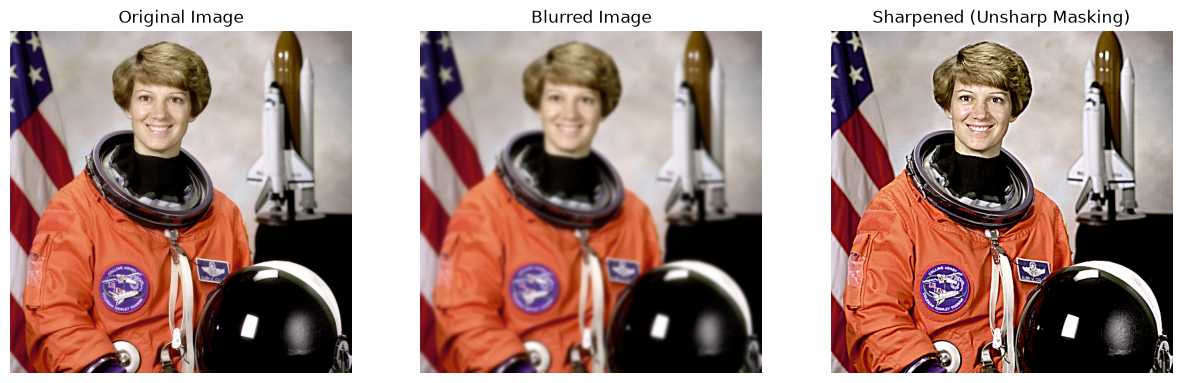

In [4]:
image = data.astronaut()

# Gaussian sigma (blur strength)
sigma = 2

# Sharpening strength
amount = 1.5

# Convert image to float32 for processing
image_float = image.astype(np.float32) / 255.0

# Apply Gaussian blur
blurred = cv2.GaussianBlur(image_float, (0, 0), sigmaX=sigma, sigmaY=sigma)

# Perform Unsharp Masking
sharpened = np.clip(image_float + amount * (image_float - blurred), 0, 1)

# Plot original, blurred, and sharpened images
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(image);      ax[0].set_title("Original Image");              ax[0].axis("off")
ax[1].imshow(blurred);    ax[1].set_title("Blurred Image");               ax[1].axis("off")
ax[2].imshow(sharpened);  ax[2].set_title("Sharpened (Unsharp Masking)"); ax[2].axis("off")
plt.show()

---


## Assessment Task 1 — 7×7 Box Filter

A **box filter** is the simplest smoothing filter: every pixel is replaced by the **average** of the pixels in a square window around it. Every weight is equal — like a blurred "box" of influence.

A 7×7 box kernel looks like:

$$K = \frac{1}{49}\begin{bmatrix} 1 & 1 & \cdots & 1 \\ 1 & 1 & \cdots & 1 \\ \vdots & & \ddots & \vdots \\ 1 & 1 & \cdots & 1 \end{bmatrix}$$

All 49 entries are `1/49` so the weights sum to 1 (preserves average brightness).

**Effect:** Blurs the image and reduces noise. Downside: also blurs edges and produces slightly "blocky" results because of the equal weights.

Steps:
1) Build the kernel manually.
2) Apply convolution. `cv2.filter2D` is the general-purpose convolution function. It takes any kernel you give it and slides it across the image.


In [5]:
import cv2
import numpy as np

# Build 7×7 box filter manually
kernel = np.ones((7, 7), dtype=np.float32) / 49

print(kernel)

[[0.02040816 0.02040816 0.02040816 0.02040816 0.02040816 0.02040816
  0.02040816]
 [0.02040816 0.02040816 0.02040816 0.02040816 0.02040816 0.02040816
  0.02040816]
 [0.02040816 0.02040816 0.02040816 0.02040816 0.02040816 0.02040816
  0.02040816]
 [0.02040816 0.02040816 0.02040816 0.02040816 0.02040816 0.02040816
  0.02040816]
 [0.02040816 0.02040816 0.02040816 0.02040816 0.02040816 0.02040816
  0.02040816]
 [0.02040816 0.02040816 0.02040816 0.02040816 0.02040816 0.02040816
  0.02040816]
 [0.02040816 0.02040816 0.02040816 0.02040816 0.02040816 0.02040816
  0.02040816]]


## Assessment Task 2 — 5×5 and 21×21 Gaussian Filters

The **Gaussian filter** is a smarter blur than the box filter. Instead of giving all pixels equal weight, it weights **nearby pixels more** than far ones, following a 2D Gaussian (bell-curve) distribution:

$$G(x,y) = \frac{1}{2\pi\sigma^2}\, e^{-\frac{x^2 + y^2}{2\sigma^2}}$$

A 5×5 Gaussian kernel (small blur):

$$\frac{1}{256}\begin{bmatrix}1 & 4 & 6 & 4 & 1\\4 & 16 & 24 & 16 & 4\\6 & 24 & 36 & 24 & 6\\4 & 16 & 24 & 16 & 4\\1 & 4 & 6 & 4 & 1\end{bmatrix}$$

**Why prefer Gaussian over box?**
- Smoother, more natural-looking blur (no blocky artifacts)
- Preserves edges slightly better for the same blur strength
- It's the mathematically optimal tradeoff between blurring and detail preservation

**Kernel size matters:**
- Small (e.g. 5×5) → gentle blur, subtle noise reduction
- Large (e.g. 21×21) → heavy blur, washes out fine detail

In [6]:
import cv2
print("OpenCV:", cv2.__version__)

OpenCV: 5.0.0


In [7]:
import cv2
import numpy as np

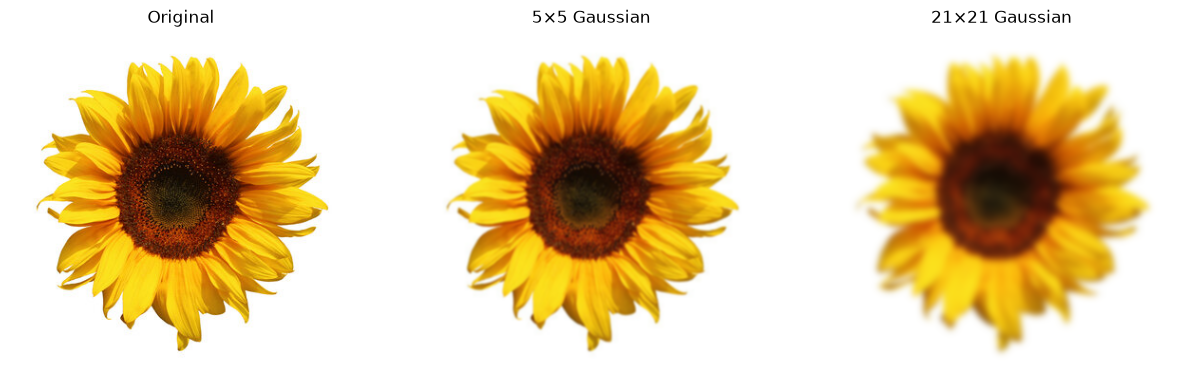

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image
img = cv2.imread("sunflower.jpg")

# 5×5 Gaussian Kernel

kernel_5 = np.array([
    [1,  4,  6,  4, 1],
    [4, 16, 24, 16, 4],
    [6, 24, 36, 24, 6],
    [4, 16, 24, 16, 4],
    [1,  4,  6,  4, 1]
], dtype=np.float32) / 256
# Apply 5×5 Gaussian filter
filtered_5 = cv2.filter2D(img, -1, kernel_5)


# 21×21 Gaussian Kernel

kernel_21_1d = cv2.getGaussianKernel(21, 0)
kernel_21 = kernel_21_1d @ kernel_21_1d.T
# Apply 21×21 Gaussian filter
filtered_21 = cv2.filter2D(img, -1, kernel_21)


plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(filtered_5, cv2.COLOR_BGR2RGB))
plt.title("5×5 Gaussian")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(filtered_21, cv2.COLOR_BGR2RGB))
plt.title("21×21 Gaussian")
plt.axis("off")

plt.show()

## Assessment Task 3 — 3×3 Laplacian Sharpening

The **Laplacian** is a *second-order* derivative operator that responds to rapid intensity changes (edges) from any direction. A common 3×3 Laplacian kernel:

$$K = \begin{bmatrix} 0 & 1 & 0 \\ 1 & -4 & 1 \\ 0 & 1 & 0 \end{bmatrix}$$

The Laplacian's raw output is **negative around bright edges and positive around dark ones**. By itself it doesn't look like an image — it looks like an edge map.

**Sharpening trick:**

$$\text{sharp} = \text{original} - \text{laplacian}$$

Subtracting the Laplacian from the original boosts edges. The result: the image looks the same, but edges pop more.

Steps (exactly as requested in the lab):
1. Read the image
2. Convert to `float32` (Laplacian can produce negatives)
3. Apply `cv2.Laplacian()`
4. Sharpen: `np.clip(image_float - laplacian, 0, 1)`
5. Plot the three images

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.3764706..1.8862746].


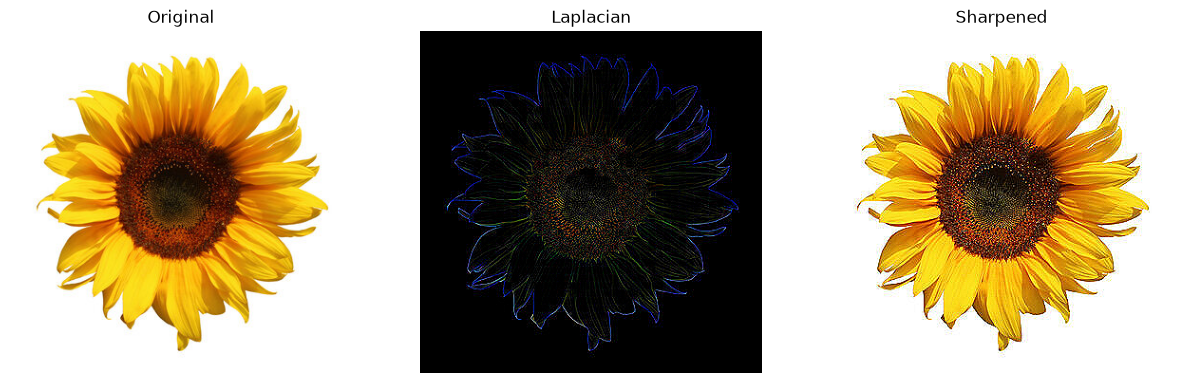

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1.Read the image
img = cv2.imread("sunflower.jpg")

# Convert BGR to RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 2. Convert image to float32 and normalize to [0, 1]
image_float = img_rgb.astype(np.float32) / 255.0

# 3×3 Laplacian
laplacian = cv2.Laplacian(image_float, cv2.CV_32F)

# 4. Sharpen the image
sharp = np.clip(image_float - laplacian, 0, 1)

# 5. Plot the three images
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image_float)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(laplacian, cmap="gray", vmin=laplacian.min(), vmax=laplacian.max())
plt.title("Laplacian")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(sharp)
plt.title("Sharpened")
plt.axis("off")

plt.show()

## Q1 — Effect of Different Box Filter Sizes
Compare 3×3, 9×9, and 15×15 box filters. Bigger kernel = stronger blur = more detail lost.

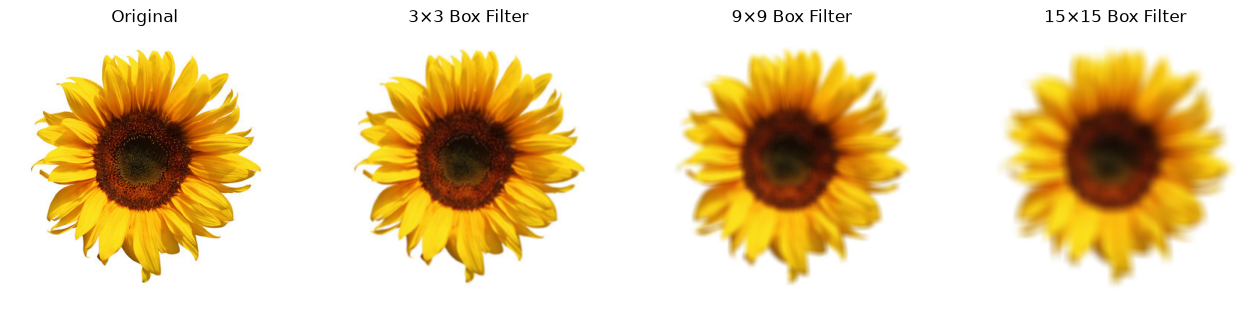

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Create box filter kernels
kernel_3 = np.ones((3, 3), dtype=np.float32) / 9
kernel_9 = np.ones((9, 9), dtype=np.float32) / 81
kernel_15 = np.ones((15, 15), dtype=np.float32) / 225

filtered_3 = cv2.filter2D(img, -1, kernel_3)
filtered_9 = cv2.filter2D(img, -1, kernel_9)
filtered_15 = cv2.filter2D(img, -1, kernel_15)

# Convert images to RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
filtered_3 = cv2.cvtColor(filtered_3, cv2.COLOR_BGR2RGB)
filtered_9 = cv2.cvtColor(filtered_9, cv2.COLOR_BGR2RGB)
filtered_15 = cv2.cvtColor(filtered_15, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(filtered_3)
plt.title("3×3 Box Filter")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(filtered_9)
plt.title("9×9 Box Filter")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(filtered_15)
plt.title("15×15 Box Filter")
plt.axis("off")

plt.show()

## Q2 — Median Filter: Removing Salt-and-Pepper Noise
The **median filter** replaces each pixel with the *median* of its neighborhood — not the mean. It's the best tool for removing "salt and pepper" noise (random black and white specks), because the median ignores extreme outliers.

Compare the median filter to a Gaussian blur on the same noisy image — Gaussian smears the specks, median removes them cleanly.

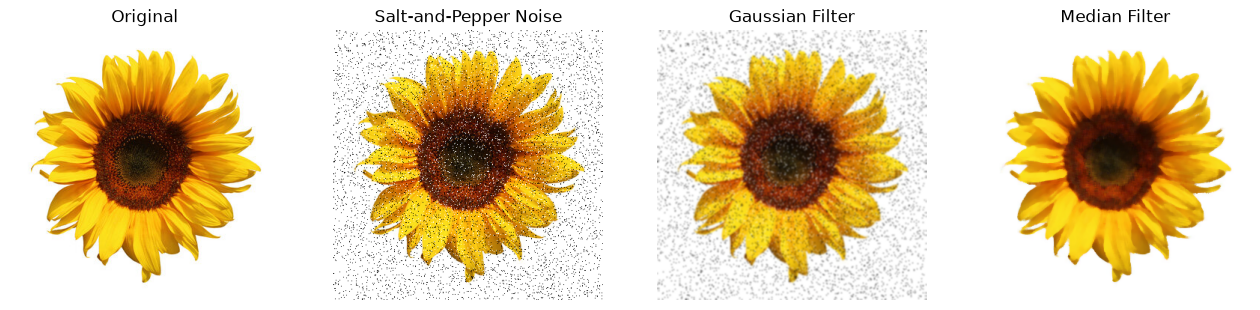

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image
img = cv2.imread("sunflower.jpg")

# Convert BGR to RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Add salt-and-pepper noise
noisy = img_rgb.copy()

# Number of noisy pixels
amount = 0.05

num_pixels = int(amount * noisy.shape[0] * noisy.shape[1])

# Salt noise (white pixels)
coords = (
    np.random.randint(0, noisy.shape[0], num_pixels),
    np.random.randint(0, noisy.shape[1], num_pixels)
)
noisy[coords] = 255

# Pepper noise (black pixels)
coords = (
    np.random.randint(0, noisy.shape[0], num_pixels),
    np.random.randint(0, noisy.shape[1], num_pixels)
)
noisy[coords] = 0

gaussian = cv2.GaussianBlur(noisy, (5, 5), 0)

median = cv2.medianBlur(noisy, 5)

plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(noisy)
plt.title("Salt-and-Pepper Noise")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(gaussian)
plt.title("Gaussian Filter")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(median)
plt.title("Median Filter")
plt.axis("off")

plt.show()

## Q3 — Bilateral Filter: Blurring While Keeping Edges Sharp
A normal Gaussian blur smooths everything — including edges. The **bilateral filter** is smarter: it blurs pixels only if they are close in *space* AND similar in *intensity*. Result: flat areas get smoothed, but edges stay crisp. Used in "beauty" filters, cartoon effects, and denoising.

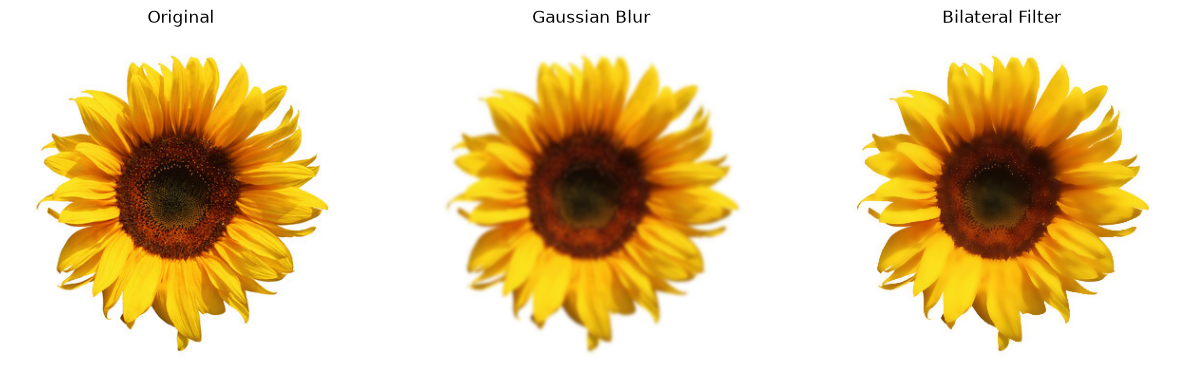

In [10]:
import cv2
import matplotlib.pyplot as plt

# Convert BGR to RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Gaussian Blur
gaussian = cv2.GaussianBlur(img, (9, 9), 0)

# Bilateral Filter
bilateral = cv2.bilateralFilter(
    img,
    d=9,
    sigmaColor=75,
    sigmaSpace=75
)

# Convert bilateral result to RGB
bilateral_rgb = cv2.cvtColor(bilateral, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(gaussian, cv2.COLOR_BGR2RGB))
plt.title("Gaussian Blur")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(bilateral_rgb)
plt.title("Bilateral Filter")
plt.axis("off")

plt.show()

---
## Summary Table

| Filter | Type | Effect | OpenCV function |
|---|---|---|---|
| **Box** | Smoothing (low-pass) | Simple average blur | `cv2.blur` or `cv2.filter2D` |
| **Gaussian** | Smoothing (low-pass) | Bell-curve weighted blur, smoother | `cv2.GaussianBlur` |
| **Median** | Smoothing (non-linear) | Removes salt-and-pepper noise | `cv2.medianBlur` |
| **Bilateral** | Smoothing (edge-preserving) | Blurs flat areas, keeps edges | `cv2.bilateralFilter` |
| **Laplacian** | Sharpening (high-pass) | Second-derivative edge enhance | `cv2.Laplacian` |
| **Unsharp mask** | Sharpening (combo) | Original + (original − blurred) | Custom (using `cv2.GaussianBlur`) |
| **Custom kernel** | Anything | Any effect you design | `cv2.filter2D` |

**Two rules to remember:**
1. For *smoothing* → use a low-pass filter (Box, Gaussian, Median, Bilateral).
2. For *sharpening* → amplify the high-frequency content (Laplacian, Unsharp mask, custom kernel with negative surround).

**End of notebook.**